# Feature Engineering Search

Programmatically discovers which feature transformations most improve a
downstream decision-tree classifier for `Problem_SKU` detection.

## Pipeline
1. **Generate candidate pool** — 4 transformation families applied to all 9
   numeric features: absolute value, square, pairwise absolute product,
   pairwise absolute difference
2. **Score every candidate** — mutual information (MI) and ANOVA F-statistic
   on the training set only (no test leakage)
3. **Select with 4 methods**
   - Top-K by MI (sweep K to find optimal set size)
   - Recursive Feature Elimination (RFE) with a DT estimator
   - L1-regularised logistic regression (`SelectFromModel`)
   - Greedy forward selection (on MI-pre-screened pool, internal val F1)
4. **Evaluate downstream** — fixed DT on the held-out test set for every
   selected feature set; compare F1, AUC, PR curve

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import (
    mutual_info_classif, f_classif, RFE, SelectFromModel,
)
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
)

path   = '../Data/SyntheticData/2026_03_31_01_52_14/std_synthetic_data_2026_03_31_01_52_14.csv'
df     = pd.read_csv(path)
target = 'Problem_SKU'
seed   = 1337

numeric_features = [
    'Global_SKU_Defect_Rate_%_std',
    'ABS_Volume_Difference_std',
    'Aisle_Hold_%_std',
    '#_Pick_Events_std',
    '#_Pick_Events_In_Clique_std',
    '#_Picks_std',
    '#_Picks_In_Clique_std',
    'Time_In_Loc_std',
    'Current_Max_Volume_std',
]
size_dummies  = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
defect_linked = df['Defect_In_Linked_Receive'].astype(int)
X_base = pd.concat([df[numeric_features], size_dummies, defect_linked], axis=1)
y      = df[target].astype(int)

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=seed, stratify=y
)
base_cols = list(X_base.columns)
print(f'Train: {X_train_base.shape}  Test: {X_test_base.shape}')
print(f'Positive rate: {y_test.mean():.3f}')
print(f'Base features: {len(base_cols)}')

Train: (220000, 13)  Test: (55000, 13)
Positive rate: 0.074
Base features: 13


In [2]:
# Short names used in generated feature labels (for readable plots)
abbrev = {
    'Global_SKU_Defect_Rate_%_std': 'defect_rate',
    'ABS_Volume_Difference_std':    'abs_vol_diff',
    'Aisle_Hold_%_std':             'aisle',
    '#_Pick_Events_std':            'pick_evts',
    '#_Pick_Events_In_Clique_std':  'pick_evts_clq',
    '#_Picks_std':                  'picks',
    '#_Picks_In_Clique_std':        'picks_clq',
    'Time_In_Loc_std':              'time_loc',
    'Current_Max_Volume_std':       'max_vol',
}

# Global registry: feature_name -> transformation type
feat_types = {col: 'base' for col in base_cols}

def generate_candidates(X):
    Xe   = X.copy()
    nc   = numeric_features
    pairs = list(combinations(nc, 2))

    # 1. |x|  -- absolute value (extremeness regardless of direction)
    for col in nc:
        name = f'|{abbrev[col]}|'
        Xe[name] = X[col].abs()
        feat_types[name] = 'abs'

    # 2. x^2  -- squared deviation (always positive, amplifies outliers more
    #            than |x|, but also squashes near-zero values to near-zero)
    for col in nc:
        name = f'{abbrev[col]}^2'
        Xe[name] = X[col] ** 2
        feat_types[name] = 'sq'

    # 3. |xi|*|xj|  -- co-extremeness: large only when BOTH are outliers.
    #   Uses absolute values to remove sign ambiguity on z-scores.
    for c1, c2 in pairs:
        name = f'|{abbrev[c1]}|*|{abbrev[c2]}|'
        Xe[name] = X[c1].abs() * X[c2].abs()
        feat_types[name] = 'prod'

    # 4. ||xi|-|xj||  -- magnitude discordance: large when one feature is
    #   extreme while the other is near its mean (an asymmetry signal).
    for c1, c2 in pairs:
        name = f'||{abbrev[c1]}|-|{abbrev[c2]}||'
        Xe[name] = (X[c1].abs() - X[c2].abs()).abs()
        feat_types[name] = 'diff'

    return Xe

X_tr_all = generate_candidates(X_train_base)
X_te_all = generate_candidates(X_test_base)
all_cols = list(X_tr_all.columns)

type_counts = pd.Series([feat_types[c] for c in all_cols]).value_counts()
print('Candidate pool:')
print(type_counts.to_string())
print(f'Total: {len(all_cols)} features')

Candidate pool:
prod    36
diff    36
base    13
abs      9
sq       9
Total: 103 features


In [3]:
# -- Scoring (training data only) -----------------------------------------
print('Computing mutual information ... (this takes ~30s)')
mi_scores = mutual_info_classif(X_tr_all, y_train, random_state=seed)
print('Computing ANOVA F-statistic ...')
f_scores, _ = f_classif(X_tr_all, y_train)

score_df = pd.DataFrame({
    'feature': all_cols,
    'type':    [feat_types[c] for c in all_cols],
    'MI':      mi_scores,
    'F_stat':  f_scores,
}).sort_values('MI', ascending=False).reset_index(drop=True)

print(f'\nTop 20 features by Mutual Information:')
print(score_df.head(20)[['feature', 'type', 'MI', 'F_stat']].to_string(index=False))

# -- Downstream evaluator -------------------------------------------------
# Fixed DT params (class_weight from best model in decision_tree.ipynb).
# Same params used for every feature-set comparison so results are comparable.
DT_PARAMS = dict(
    class_weight={False: 1, True: 3},
    max_depth=8,
    min_samples_leaf=50,
    random_state=seed,
)

def eval_downstream(cols, label=''):
    dt = DecisionTreeClassifier(**DT_PARAMS)
    dt.fit(X_tr_all[cols], y_train)
    proba = dt.predict_proba(X_te_all[cols])[:, 1]
    best_f1, best_t, best_p, best_r = 0.0, 0.5, 0.0, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f = f1_score(y_test, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
            best_p = precision_score(y_test, preds, zero_division=0)
            best_r = recall_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    return dict(label=label, proba=proba, cols=list(cols),
                f1=best_f1, p=best_p, r=best_r, t=best_t,
                auc=auc, ap=ap, n=len(cols))

# Baseline: original 13 features, no engineering
res_base = eval_downstream(base_cols, 'Base (13 features)')
print(f'\nBaseline downstream F1 = {res_base["f1"]:.4f}  AUC = {res_base["auc"]:.4f}')

Computing mutual information ... (this takes ~30s)
Computing ANOVA F-statistic ...

Top 20 features by Mutual Information:
                      feature type       MI       F_stat
        #_Picks_In_Clique_std base 0.032892 18541.922161
                  picks_clq^2   sq 0.031196 14164.234803
                  |picks_clq|  abs 0.030784 16625.041391
          |picks|*|picks_clq| prod 0.030529 16771.928705
  |pick_evts_clq|*|picks_clq| prod 0.028292 17572.111317
          |aisle|*|picks_clq| prod 0.026172 16864.453630
        |picks_clq|*|max_vol| prod 0.025422 18058.577916
   |abs_vol_diff|*|picks_clq| prod 0.024015 17277.523684
      |pick_evts|*|picks_clq| prod 0.023604  9870.999240
        ||picks|-|picks_clq|| diff 0.022942  7876.833403
       |picks_clq|*|time_loc| prod 0.021701  8738.487710
    |defect_rate|*|picks_clq| prod 0.020942 13379.254807
||pick_evts_clq|-|picks_clq|| diff 0.020750  7843.392719
    ||pick_evts|-|picks_clq|| diff 0.020662  6112.781515
        ||aisle|-|pick

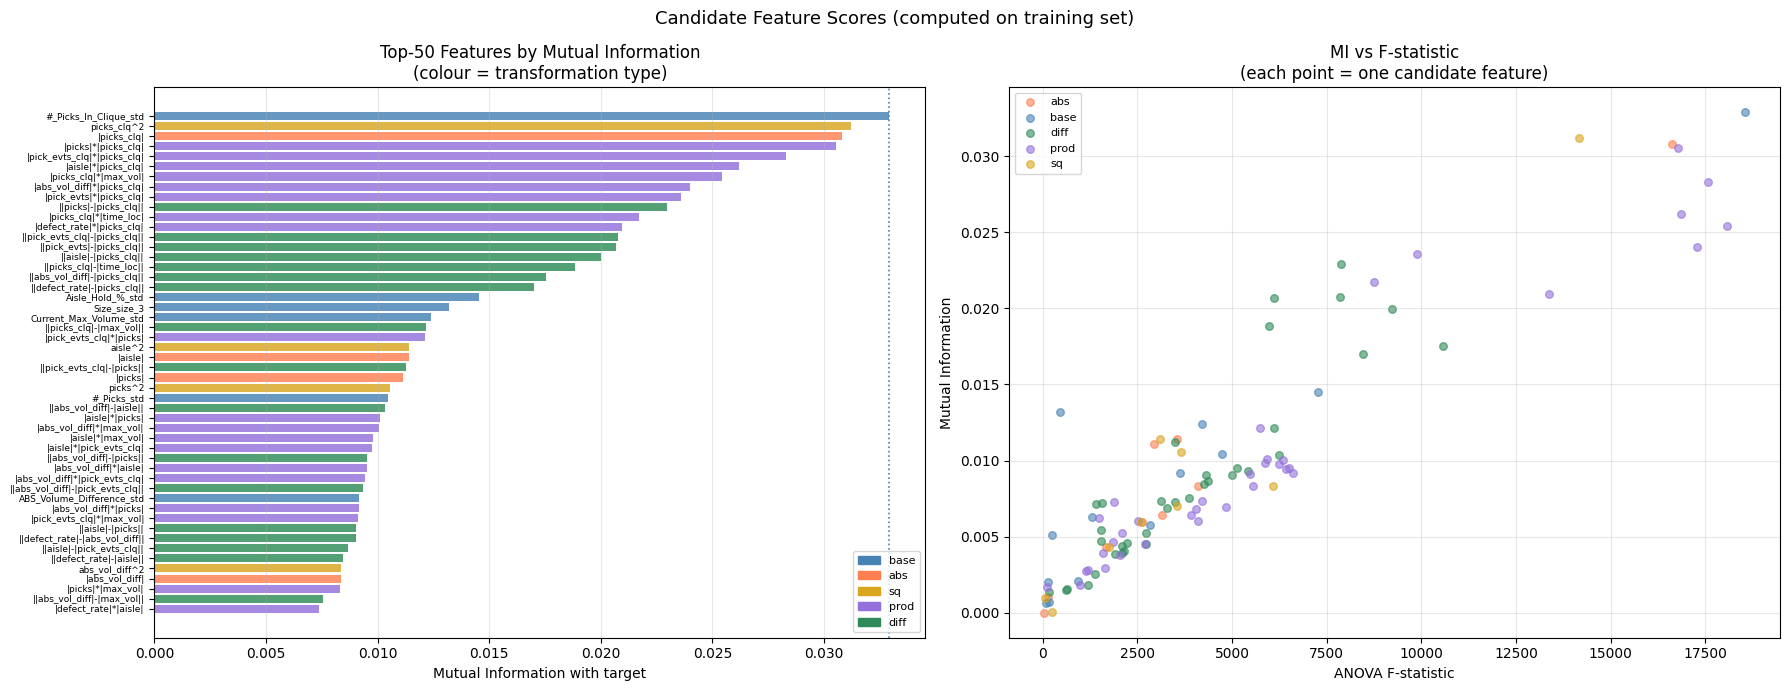

In [4]:
TYPE_COLORS = {
    'base': 'steelblue',
    'abs':  'coral',
    'sq':   'goldenrod',
    'prod': 'mediumpurple',
    'diff': 'seagreen',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -- Left: top-50 by MI, coloured by type ---------------------------------
ax = axes[0]
top50 = score_df.head(50)
colors = [TYPE_COLORS[t] for t in top50['type']]
bars = ax.barh(range(len(top50)), top50['MI'], color=colors, alpha=0.82)
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50['feature'], fontsize=6.5)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information with target')
ax.set_title('Top-50 Features by Mutual Information\n(colour = transformation type)')
ax.axvline(score_df.loc[score_df['type'] == 'base', 'MI'].max(),
           color='steelblue', linestyle=':', linewidth=1.2,
           label='Best base MI')
handles = [mpatches.Patch(color=v, label=k) for k, v in TYPE_COLORS.items()]
ax.legend(handles=handles, fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)

# -- Right: MI vs F_stat scatter, coloured by type -----------------------
ax2 = axes[1]
for ttype, grp in score_df.groupby('type'):
    ax2.scatter(grp['F_stat'], grp['MI'], color=TYPE_COLORS[ttype],
                alpha=0.6, label=ttype, s=30)
ax2.set_xlabel('ANOVA F-statistic')
ax2.set_ylabel('Mutual Information')
ax2.set_title('MI vs F-statistic\n(each point = one candidate feature)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Candidate Feature Scores (computed on training set)', fontsize=13)
plt.tight_layout()
plt.show()

    K       F1        P        R      AUC       AP
--------------------------------------------------
    5   0.3536    0.267    0.525   0.7530   0.2849
   10   0.3793    0.353    0.409   0.7835   0.3283
   13   0.3799    0.351    0.414   0.7867   0.3287
   15   0.3846    0.350    0.427   0.7966   0.3321
   20   0.4152    0.362    0.487   0.8237   0.3641
   25   0.4355    0.426    0.446   0.8339   0.3907
   30   0.4480    0.399    0.510   0.8435   0.4094
   40   0.4463    0.423    0.472   0.8453   0.4195
   50   0.4464    0.421    0.475   0.8424   0.4194
  103   0.4468    0.397    0.510   0.8427   0.4112

Best K = 30  F1 = 0.4480


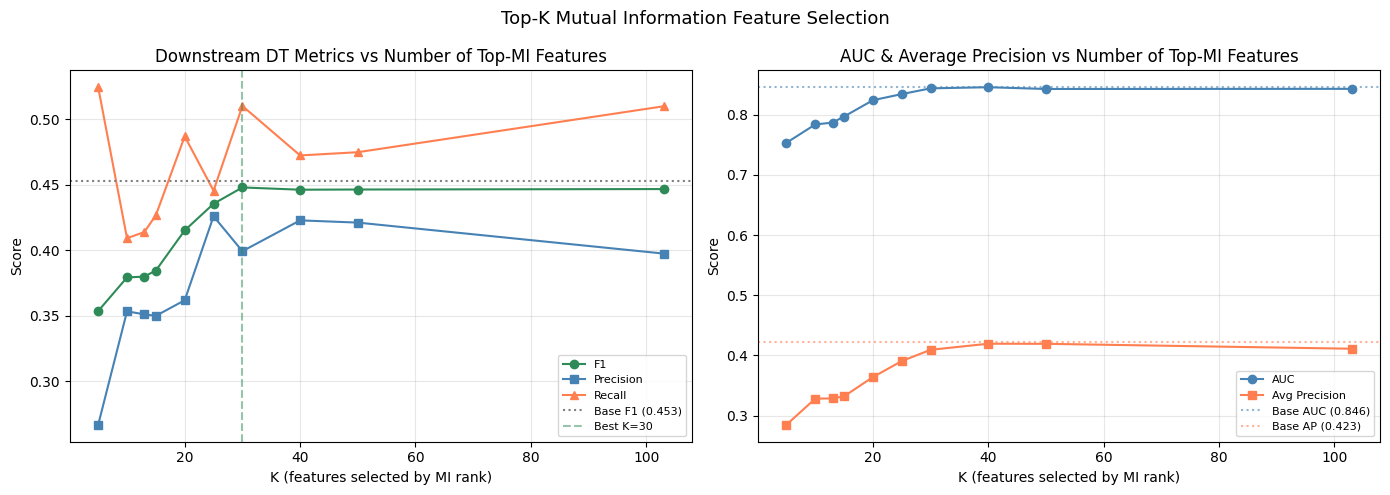

In [5]:
k_values = [5, 10, 13, 15, 20, 25, 30, 40, 50, len(all_cols)]
topk_results = []

print(f"{'K':>5}  {'F1':>7}  {'P':>7}  {'R':>7}  {'AUC':>7}  {'AP':>7}")
print('-' * 50)
for k in k_values:
    cols = score_df['feature'].head(k).tolist()
    res  = eval_downstream(cols, f'Top-{k} MI')
    topk_results.append(res)
    print(f'{k:>5}  {res["f1"]:>7.4f}  {res["p"]:>7.3f}  {res["r"]:>7.3f}  '
          f'{res["auc"]:>7.4f}  {res["ap"]:>7.4f}')

best_k_idx = max(range(len(topk_results)), key=lambda i: topk_results[i]['f1'])
best_topk  = topk_results[best_k_idx]
print(f'\nBest K = {k_values[best_k_idx]}  F1 = {best_topk["f1"]:.4f}')

# -- Plot: metrics vs K ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(k_values, [r['f1']  for r in topk_results], marker='o', color='seagreen',  label='F1')
ax.plot(k_values, [r['p']   for r in topk_results], marker='s', color='steelblue', label='Precision')
ax.plot(k_values, [r['r']   for r in topk_results], marker='^', color='coral',     label='Recall')
ax.axhline(res_base['f1'], color='gray', linestyle=':', label=f'Base F1 ({res_base["f1"]:.3f})')
ax.axvline(k_values[best_k_idx], color='seagreen', linestyle='--', alpha=0.5,
           label=f'Best K={k_values[best_k_idx]}')
ax.set_xlabel('K (features selected by MI rank)')
ax.set_ylabel('Score')
ax.set_title('Downstream DT Metrics vs Number of Top-MI Features')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(k_values, [r['auc'] for r in topk_results], marker='o', color='steelblue', label='AUC')
ax2.plot(k_values, [r['ap']  for r in topk_results], marker='s', color='coral',     label='Avg Precision')
ax2.axhline(res_base['auc'], color='steelblue', linestyle=':', alpha=0.6, label=f'Base AUC ({res_base["auc"]:.3f})')
ax2.axhline(res_base['ap'],  color='coral',     linestyle=':', alpha=0.6, label=f'Base AP ({res_base["ap"]:.3f})')
ax2.set_xlabel('K (features selected by MI rank)')
ax2.set_ylabel('Score')
ax2.set_title('AUC & Average Precision vs Number of Top-MI Features')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle('Top-K Mutual Information Feature Selection', fontsize=13)
plt.tight_layout(); plt.show()

In [6]:
# -- Recursive Feature Elimination ----------------------------------------
# Uses DT as the estimator; step=10 removes 10 features per iteration.
N_RFE = 15
rfe_est = DecisionTreeClassifier(
    class_weight={False: 1, True: 3}, max_depth=6, random_state=seed
)
rfe = RFE(rfe_est, n_features_to_select=N_RFE, step=10)
print(f'Fitting RFE (selecting {N_RFE} from {len(all_cols)}) ...')
rfe.fit(X_tr_all, y_train)
rfe_cols = [c for c, sel in zip(all_cols, rfe.support_) if sel]
rfe_type_counts = pd.Series([feat_types[c] for c in rfe_cols]).value_counts()
print(f'RFE selected {len(rfe_cols)} features:')
print(rfe_type_counts.to_string())
print('  Features:', rfe_cols)
res_rfe = eval_downstream(rfe_cols, f'RFE (n={len(rfe_cols)})')
print(f'RFE  F1={res_rfe["f1"]:.4f}  AUC={res_rfe["auc"]:.4f}')

# -- L1 Logistic Regression SelectFromModel -------------------------------
# L1 penalty drives many coefficients to 0; non-zero ones are kept.
# class_weight='balanced' corrects for imbalance during coefficient fitting.
print('\nFitting L1 Logistic Regression ...')
l1_lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.05,
    class_weight='balanced', max_iter=1000, random_state=seed
)
sfm = SelectFromModel(l1_lr, max_features=25)
sfm.fit(X_tr_all, y_train)
l1_cols = [c for c, sel in zip(all_cols, sfm.get_support()) if sel]
l1_type_counts = pd.Series([feat_types[c] for c in l1_cols]).value_counts()
print(f'L1-LR selected {len(l1_cols)} features:')
print(l1_type_counts.to_string())
print('  Features:', l1_cols)
res_l1 = eval_downstream(l1_cols, f'L1-LR (n={len(l1_cols)})')
print(f'L1-LR  F1={res_l1["f1"]:.4f}  AUC={res_l1["auc"]:.4f}')

# -- Feature overlap between the two methods ------------------------------
overlap = set(rfe_cols) & set(l1_cols)
print(f'\nRFE / L1-LR overlap: {len(overlap)} features')
print(sorted(overlap))

Fitting RFE (selecting 15 from 103) ...
RFE selected 15 features:
prod    5
diff    5
base    4
abs     1
  Features: ['Aisle_Hold_%_std', '#_Picks_std', '#_Picks_In_Clique_std', 'Current_Max_Volume_std', '|pick_evts_clq|', '|defect_rate|*|abs_vol_diff|', '|defect_rate|*|picks|', '|abs_vol_diff|*|pick_evts_clq|', '|aisle|*|pick_evts_clq|', '|pick_evts_clq|*|picks|', '||defect_rate|-|abs_vol_diff||', '||defect_rate|-|pick_evts_clq||', '||abs_vol_diff|-|aisle||', '||abs_vol_diff|-|pick_evts_clq||', '||aisle|-|pick_evts_clq||']
RFE  F1=0.4481  AUC=0.8463

Fitting L1 Logistic Regression ...


c:\Users\myfir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\myfir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1-LR selected 25 features:
base    10
abs      6
sq       4
diff     4
prod     1
  Features: ['Global_SKU_Defect_Rate_%_std', 'ABS_Volume_Difference_std', 'Aisle_Hold_%_std', '#_Picks_std', '#_Picks_In_Clique_std', 'Current_Max_Volume_std', 'Size_size_2', 'Size_size_3', 'Size_size_4', 'Defect_In_Linked_Receive', '|abs_vol_diff|', '|aisle|', '|pick_evts_clq|', '|picks|', '|picks_clq|', '|max_vol|', 'pick_evts_clq^2', 'picks^2', 'picks_clq^2', 'max_vol^2', '|pick_evts_clq|*|picks|', '||defect_rate|-|picks||', '||defect_rate|-|max_vol||', '||abs_vol_diff|-|pick_evts_clq||', '||pick_evts_clq|-|picks||']
L1-LR  F1=0.4529  AUC=0.8437

RFE / L1-LR overlap: 7 features
['#_Picks_In_Clique_std', '#_Picks_std', 'Aisle_Hold_%_std', 'Current_Max_Volume_std', '|pick_evts_clq|', '|pick_evts_clq|*|picks|', '||abs_vol_diff|-|pick_evts_clq||']


Greedy forward selection  (pool = MI top-25):
  Stopping when best gain < 0.001

  + 1  [base]  #_Picks_In_Clique_std                     val_F1=0.3551
  + 2  [diff]  ||abs_vol_diff|-|picks_clq||              val_F1=0.3645
  + 3  [base]  Aisle_Hold_%_std                          val_F1=0.3815
  + 4  [base]  Current_Max_Volume_std                    val_F1=0.4122
  + 5  [prod]  |pick_evts_clq|*|picks|                   val_F1=0.4220
  + 6  [prod]  |abs_vol_diff|*|picks_clq|                val_F1=0.4244
  Stopped at 6 features: gain 0.0000 < 0.001

Greedy test F1=0.4336  AUC=0.8353


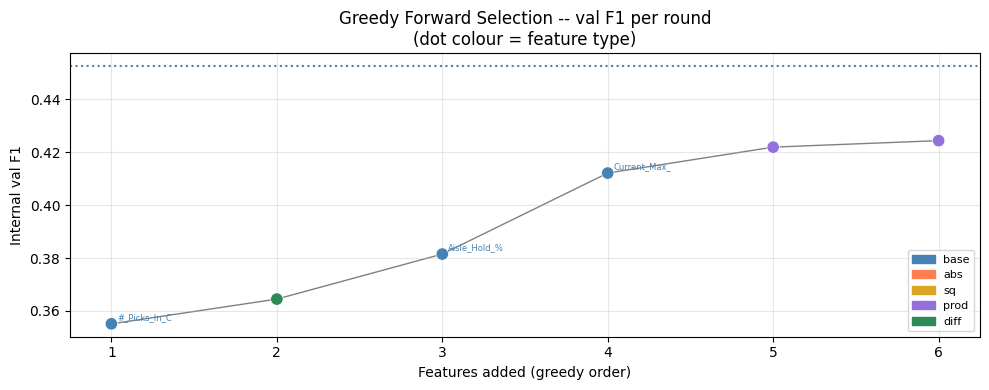

In [7]:
# Pool = MI top-25 (pre-screening keeps the search tractable).
# Internal 75/25 split: fit DT on 75% of train, score on remaining 25%.
# Stopping rule: stop when adding the best remaining feature raises
#   internal val F1 by less than min_delta = 0.001.
POOL_SIZE = 25
MIN_DELTA = 0.001

pool = score_df['feature'].head(POOL_SIZE).tolist()

X_fi, X_fv, y_fi, y_fv = train_test_split(
    X_tr_all[pool], y_train, test_size=0.25, random_state=seed, stratify=y_train
)

# Lighter DT for internal scoring (faster iteration)
FAST_DT = dict(
    class_weight={False: 1, True: 3},
    max_depth=5,
    min_samples_leaf=100,
    random_state=seed,
)

def quick_f1(cols):
    dt = DecisionTreeClassifier(**FAST_DT)
    dt.fit(X_fi[cols], y_fi)
    proba = dt.predict_proba(X_fv[cols])[:, 1]
    best = 0.0
    for t in np.arange(0.10, 0.90, 0.05):
        preds = (proba >= t).astype(int)
        if preds.sum() > 0:
            best = max(best, f1_score(y_fv, preds, zero_division=0))
    return best

selected, remaining = [], pool[:]
current_f1 = 0.0
greedy_log = []

print(f'Greedy forward selection  (pool = MI top-{POOL_SIZE}):')
print(f'  Stopping when best gain < {MIN_DELTA}')
print()

for _ in range(POOL_SIZE):
    if not remaining:
        break
    best_gain, best_feat = -1.0, None
    for feat in remaining:
        score = quick_f1(selected + [feat])
        if score > best_gain:
            best_gain, best_feat = score, feat
    if best_gain < current_f1 + MIN_DELTA:
        print(f'  Stopped at {len(selected)} features: gain {best_gain - current_f1:.4f} < {MIN_DELTA}')
        break
    selected.append(best_feat)
    remaining.remove(best_feat)
    current_f1 = best_gain
    ftype = feat_types[best_feat]
    greedy_log.append((len(selected), best_feat, ftype, current_f1))
    print(f'  +{len(selected):2d}  [{ftype:4s}]  {best_feat:<40s}  val_F1={current_f1:.4f}')

res_greedy = eval_downstream(selected, f'Greedy fwd (n={len(selected)})')
print(f'\nGreedy test F1={res_greedy["f1"]:.4f}  AUC={res_greedy["auc"]:.4f}')

# -- Plot: greedy selection trajectory ------------------------------------
if greedy_log:
    rounds  = [row[0] for row in greedy_log]
    val_f1s = [row[3] for row in greedy_log]
    gtypes  = [row[2] for row in greedy_log]
    gcolors = [TYPE_COLORS[t] for t in gtypes]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rounds, val_f1s, color='gray', linewidth=1, zorder=1)
    ax.scatter(rounds, val_f1s, c=gcolors, s=80, zorder=2, edgecolors='white', linewidths=0.5)
    for row in greedy_log:
        ax.annotate(row[1].split('|')[-1].rstrip('|') if '|' in row[1] else row[1][:12],
                    (row[0], row[3]), textcoords='offset points',
                    xytext=(4, 3), fontsize=6, color=TYPE_COLORS[row[2]])
    ax.axhline(res_base['f1'], color='steelblue', linestyle=':', label=f'Base val F1 ref')
    ax.set_xlabel('Features added (greedy order)')
    ax.set_ylabel('Internal val F1')
    ax.set_title('Greedy Forward Selection -- val F1 per round\n(dot colour = feature type)')
    handles = [mpatches.Patch(color=v, label=k) for k, v in TYPE_COLORS.items()]
    ax.legend(handles=handles, fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

Feature Selection Method Comparison (test set):
            Method  N feats     F1  Precision  Recall    AUC     AP  Threshold
Base (13 features)       13 0.4526      0.419   0.492 0.8458 0.4227       0.45
         Top-30 MI       30 0.4480      0.399   0.510 0.8435 0.4094       0.41
        RFE (n=15)       15 0.4481      0.401   0.507 0.8463 0.4243       0.43
      L1-LR (n=25)       25 0.4529      0.419   0.493 0.8437 0.4179       0.44
  Greedy fwd (n=6)        6 0.4336      0.404   0.468 0.8353 0.3941       0.45

Winner by F1: L1-LR (n=25)
  F1=0.4529  P=0.419  R=0.493  AUC=0.8437
  Features (25):
    [base]  Global_SKU_Defect_Rate_%_std
    [base]  ABS_Volume_Difference_std
    [base]  Aisle_Hold_%_std
    [base]  #_Picks_std
    [base]  #_Picks_In_Clique_std
    [base]  Current_Max_Volume_std
    [base]  Size_size_2
    [base]  Size_size_3
    [base]  Size_size_4
    [base]  Defect_In_Linked_Receive
    [abs ]  |abs_vol_diff|
    [abs ]  |aisle|
    [abs ]  |pick_evts_clq|
    [a

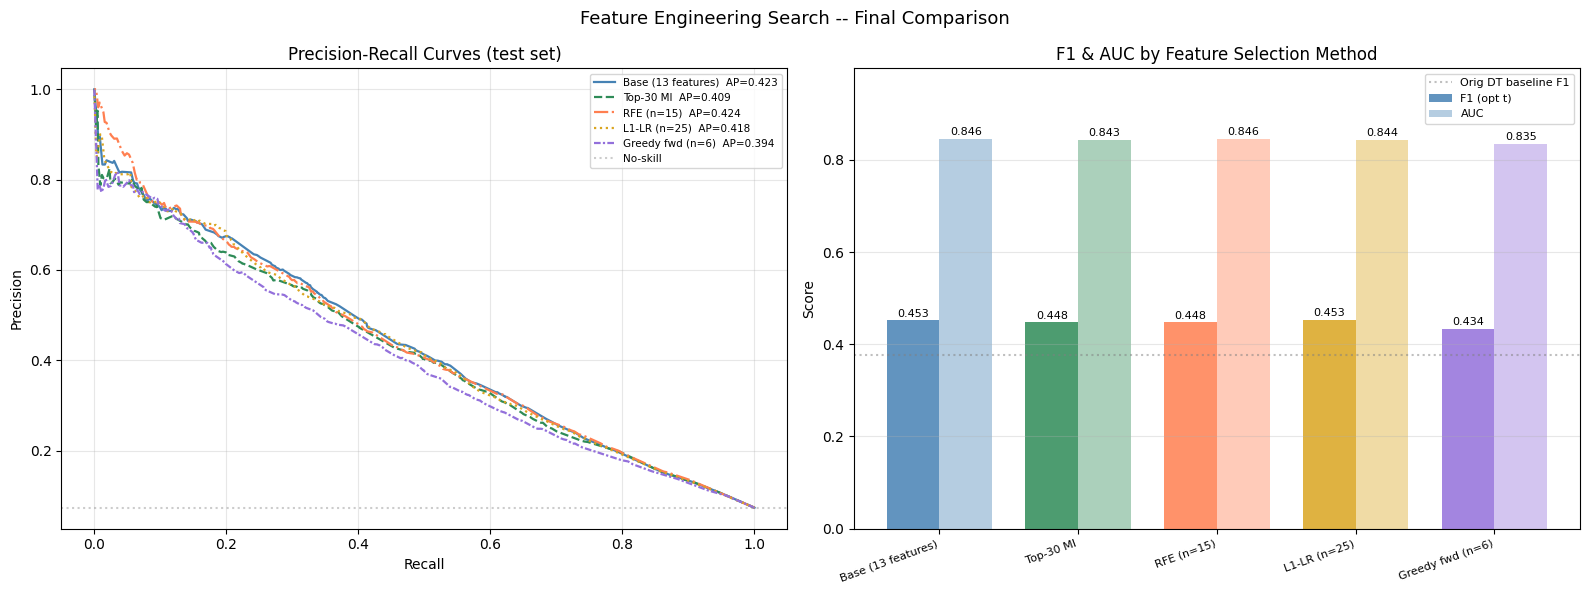

In [8]:
# -- Summary table --------------------------------------------------------
all_results = [res_base, best_topk, res_rfe, res_l1, res_greedy]

rows = []
for res in all_results:
    rows.append({
        'Method':    res['label'],
        'N feats':   res['n'],
        'F1':        round(res['f1'],  4),
        'Precision': round(res['p'],   3),
        'Recall':    round(res['r'],   3),
        'AUC':       round(res['auc'], 4),
        'AP':        round(res['ap'],  4),
        'Threshold': round(res['t'],   2),
    })
comp_df = pd.DataFrame(rows)
print('Feature Selection Method Comparison (test set):')
print(comp_df.to_string(index=False))

best_res = max(all_results, key=lambda r: r['f1'])
print(f'\nWinner by F1: {best_res["label"]}')
print(f'  F1={best_res["f1"]:.4f}  P={best_res["p"]:.3f}  R={best_res["r"]:.3f}  AUC={best_res["auc"]:.4f}')
print(f'  Features ({best_res["n"]}):')
for c in best_res['cols']:
    print(f'    [{feat_types[c]:4s}]  {c}')

# -- Plots ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR curves
ax = axes[0]
line_styles = ['-', '--', '-.', ':', (0, (3,1,1,1)), '--']
line_colors = ['steelblue', 'seagreen', 'coral', 'goldenrod', 'mediumpurple', 'gray']
for res, ls, lc in zip(all_results, line_styles, line_colors):
    p, r, _ = precision_recall_curve(y_test, res['proba'])
    ax.plot(r, p, linestyle=ls, color=lc, linewidth=1.6,
            label=f'{res["label"]}  AP={res["ap"]:.3f}')
ax.axhline(y_test.mean(), color='gray', linestyle=':', alpha=0.4, label='No-skill')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (test set)')
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

# F1 bar chart
ax2 = axes[1]
labels = [r['label'] for r in all_results]
f1s    = [r['f1']    for r in all_results]
aucs   = [r['auc']   for r in all_results]
x      = np.arange(len(labels))
w      = 0.38
b1 = ax2.bar(x - w/2, f1s,  w, color=line_colors[:len(labels)], alpha=0.85, label='F1 (opt t)')
b2 = ax2.bar(x + w/2, aucs, w, color=line_colors[:len(labels)], alpha=0.40, label='AUC')
for bar, val in zip(b1, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(b2, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax2.axhline(0.377, color='gray', linestyle=':', alpha=0.5, label='Orig DT baseline F1')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax2.set_ylim(0, max(aucs) * 1.18)
ax2.set_ylabel('Score')
ax2.set_title('F1 & AUC by Feature Selection Method')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Feature Engineering Search -- Final Comparison', fontsize=13)
plt.tight_layout(); plt.show()